<a href="https://colab.research.google.com/github/Malvocado/Machine_Learing_Final_Project/blob/main/Random_forest_regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BMW Price Prediction — Random Forest Regressor


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})
%matplotlib inline


## 1. Load & Inspect


In [ ]:
df = pd.read_csv("BMW_sales_data_after_processing.csv")
print(f"Shape: {df.shape}")
print(f"Dtypes:\n{df.dtypes}")
df.head(3)


Shape: (50000, 11)
Dtypes:
Model                       str
Year                      int64
Region                      str
Color                       str
Fuel_Type                   str
Transmission                str
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification        str
dtype: object


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low


## 2. EDA


In [ ]:
print('Nulls:', df.isnull().sum().to_dict())
print(f"\nPrice_USD stats:\n{df['Price_USD'].describe()}")


Nulls: {'Model': 0, 'Year': 0, 'Region': 0, 'Color': 0, 'Fuel_Type': 0, 'Transmission': 0, 'Engine_Size_L': 0, 'Mileage_KM': 0, 'Price_USD': 0, 'Sales_Volume': 0, 'Sales_Classification': 0}

Price_USD stats:
count     50000.000000
mean      75034.600900
std       25998.248882
min       30000.000000
25%       52434.750000
50%       75011.500000
75%       97628.250000
max      119998.000000
Name: Price_USD, dtype: float64


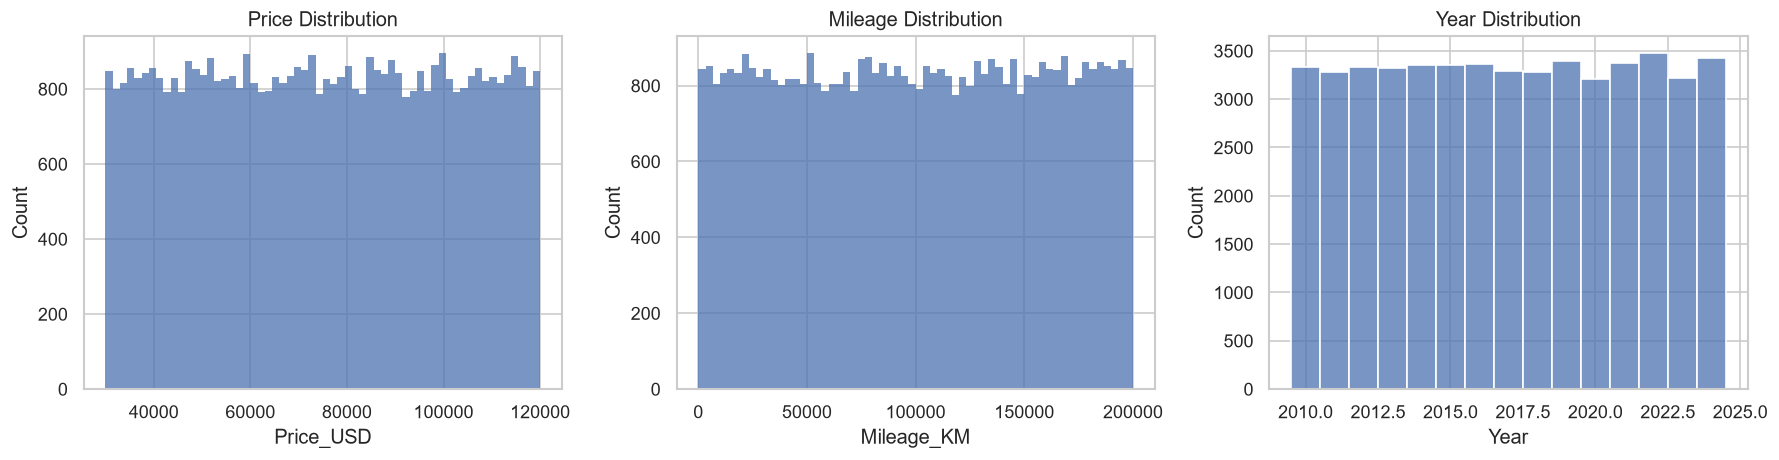

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Price_USD'], bins=60, edgecolor='none', ax=axes[0])
axes[0].set_title('Price Distribution')
sns.histplot(df['Mileage_KM'], bins=60, edgecolor='none', ax=axes[1])
axes[1].set_title('Mileage Distribution')
sns.histplot(df['Year'], bins=15, discrete=True, ax=axes[2])
axes[2].set_title('Year Distribution')
plt.tight_layout()
plt.show()


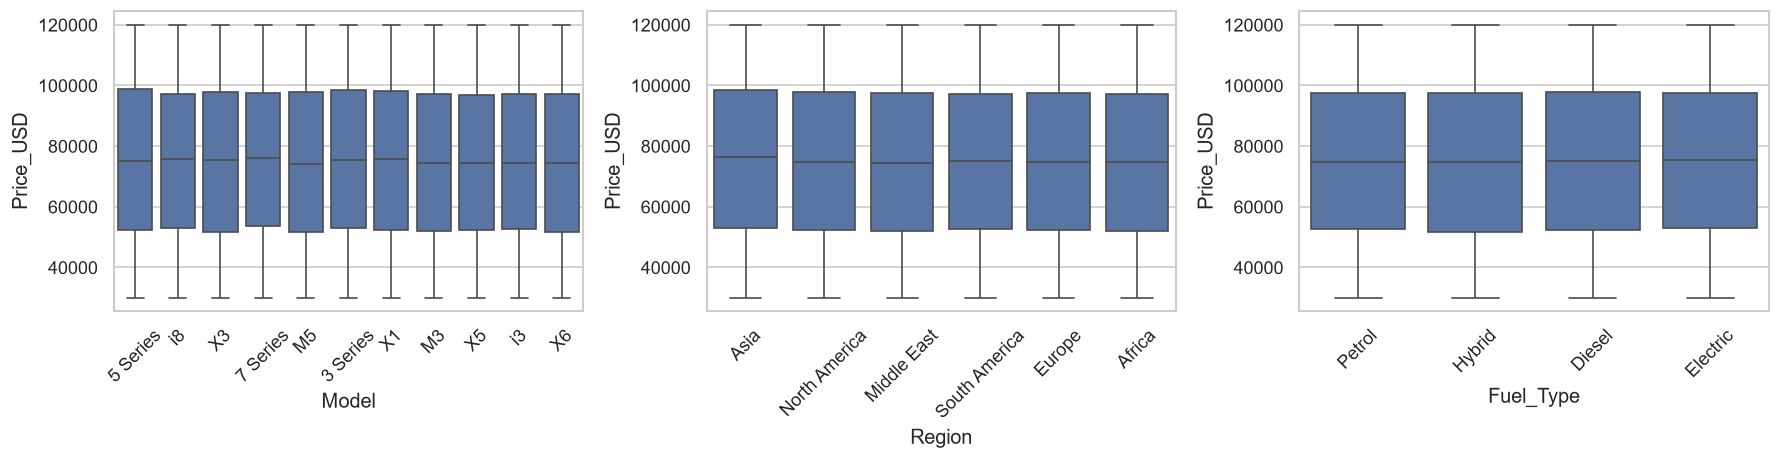

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Model', 'Region', 'Fuel_Type']):
    sns.boxplot(data=df, x=col, y='Price_USD', ax=ax)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Dropping Sales_Classification (leakage — derived from Sales_Volume) and Sales_Volume (user choice).


In [ ]:
cat_cols = ["Model", "Region", "Color", "Fuel_Type", "Transmission"]
num_cols = ["Year", "Engine_Size_L", "Mileage_KM"]
target = "Price_USD"

X = df[cat_cols + num_cols]
y = df[target]


## 3. Train / Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")


Train: 40,000  Test: 10,000


## 4. Preprocessing Pipeline


In [ ]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", StandardScaler(), num_cols),
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
])


## 5. GridSearchCV


In [ ]:
param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [10, 20, None],
    "rf__min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(
    pipeline, param_grid, cv=3,
    scoring="r2", n_jobs=-1, verbose=1,
)
print('Fitting GridSearchCV (3x9 = 27 fits)...')
grid.fit(X_train, y_train)

print(f'\nBest params: {grid.best_params_}')
print(f'Best CV R\u00b2: {grid.best_score_:.4f}')


Fitting GridSearchCV (3x9 = 27 fits)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best params: {'rf__max_depth': 10, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Best CV R²: -0.0022


## 6. Evaluate on Test Set


In [ ]:
y_pred = grid.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Test R\u00b2:     {r2:.4f}')
print(f'Test MAE:    ${mae:,.0f}')
print(f'Test RMSE:   ${rmse:,.0f}')


Test R²:     -0.0012
Test MAE:    $22,569
Test RMSE:   $26,033


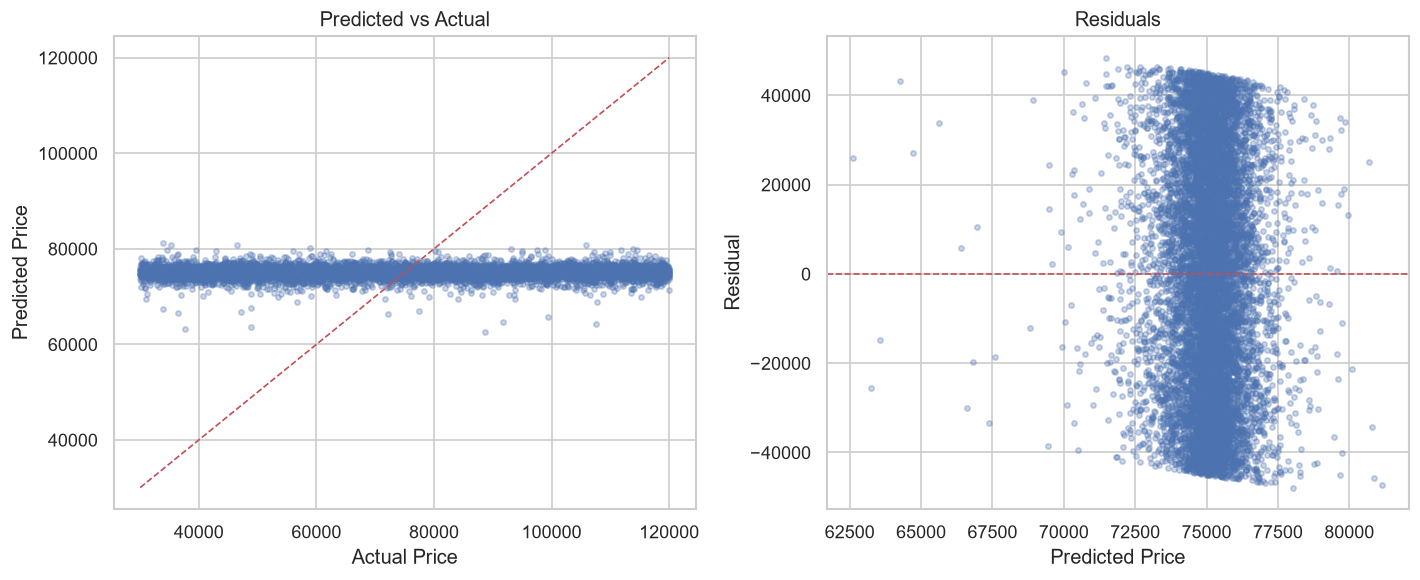

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set(xlabel='Actual Price', ylabel='Predicted Price', title='Predicted vs Actual')

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set(xlabel='Predicted Price', ylabel='Residual', title='Residuals')

plt.tight_layout()
plt.show()


## 7. Feature Importance


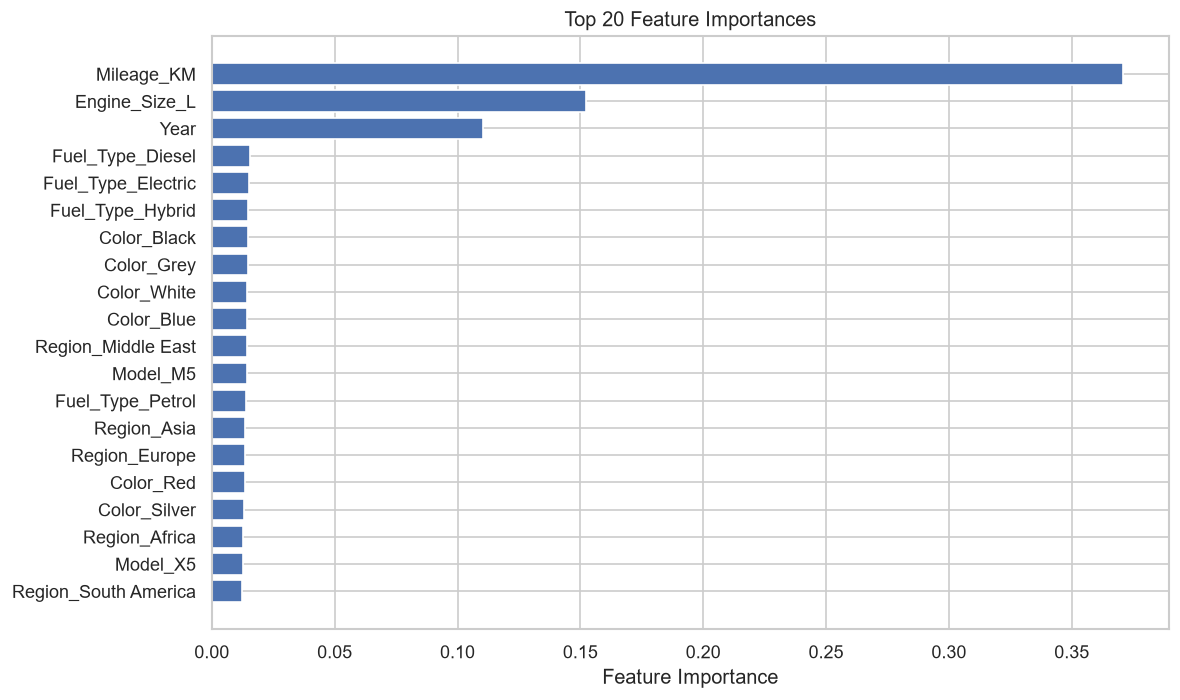

In [ ]:
best_rf = grid.best_estimator_.named_steps["rf"]
prep = grid.best_estimator_.named_steps["prep"]

# Get feature names after OneHot
cat_names = prep.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
feature_names = cat_names + num_cols

importances = best_rf.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
top_n = 20
ax.barh(range(top_n), importances[idx][:top_n][::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in idx[:top_n]][::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()


In [ ]:
# Quick residual diagnostics
res_std = np.std(residuals)
print(f'Residual std: ${res_std:,.0f}')
print(f'Residuals within 1\u03c3: {np.mean(np.abs(residuals) < res_std)*100:.1f}%')
print(f'Residuals within 2\u03c3: {np.mean(np.abs(residuals) < 2*res_std)*100:.1f}%')


Residual std: $26,032
Residuals within 1σ: 57.6%
Residuals within 2σ: 100.0%
